# Bond_Sim: pipeline walkthrough

**Question.** How likely is a US sovereign-debt doom loop (debt growth pushes yields up, higher yields push
interest cost and future debt growth up), what interrupts it, who is hurt if nothing does, and for how long.

This notebook runs every phase of the engine on real data and explains what each step does and why it is
built the way it is. Each section maps to a module in `src/bond_sim/` and to a decision record in `docs/decisions/`.
Numbers that are placeholders awaiting a human call are listed in `PARAMETERS.md`; nothing in this notebook
should be read as a finding until those are replaced or defended.

Phases 1-2 (the hand-coded toy book, Problems 1-5) live in `main.ipynb`; `tests/test_toy_book.py` pins their
numbers so the engine below can never drift from what was hand-verified.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
from bond_sim.config import load
from bond_sim.calendar import MonthlyGrid

AS_OF = pd.Timestamp("2026-09-15")
cfg = load()
grid = MonthlyGrid.from_history_plus_horizon(cfg.data.history_start, AS_OF, cfg.calendar.horizon_years)
print(grid, "| config hash", cfg.content_hash())

MonthlyGrid(1980-01-01 .. 2056-09-01, M=921) | config hash e6a47cd7e9b8


## 1. Point-in-time data (decision 0002)

Every macro series is stored as its **full revision history** from ALFRED: one row per observation per
vintage window. "What was known on date X" is then one boolean mask (`VintageFrame.as_of`), and the
`@point_in_time` decorator asserts that nothing a loader returns postdates its `as_of`.

Below: GDP for 2009Q3 was first published at 14,301.5 and has been revised repeatedly since. An analysis
dated November 2009 sees the first number; today's FRED shows the last one. Lead/lag and regime claims
in the paper are made on the former.

In [2]:
from bond_sim.data import FredClient, SERIES
fc = FredClient()
gdp = fc.fetch_vintages("GDP")
display(gdp.revisions("GDP", "2009-07-01").head(6))
print("known on 2009-11-15:", gdp.as_of("2009-11-15").set_index("date").loc["2009-07-01", "value"],
      "| latest:", gdp.latest().set_index("date").loc["2009-07-01", "value"])

,series_id,date,value,realtime_start,realtime_end,backfilled
0,GDP,2009-07-01,14301.5,2009-10-29,2009-11-23,False
1,GDP,2009-07-01,14266.3,2009-11-24,2009-12-21,False
2,GDP,2009-07-01,14242.1,2009-12-22,2010-07-29,False
3,GDP,2009-07-01,14114.7,2010-07-30,2011-07-28,False
4,GDP,2009-07-01,13920.5,2011-07-29,2012-07-26,False
5,GDP,2009-07-01,13952.2,2012-07-27,2013-07-30,False


known on 2009-11-15: 14301.5 | latest: 14448.882


ALFRED only started tracking most series in the 1990s-2000s. Observations older than a series' first vintage
carry a **backfilled** publication timestamp (observation date plus a conservative typical lag) and are flagged,
so the paper can state exactly which point-in-time results rest on true vintages.

In [3]:
cov = fc.vintage_coverage(["GDP", "DGS10", "UNRATE", "MTSDS133FMS", "PAYEMS", "FYGFGDQ188S"])
display(cov[["freq", "first_obs", "first_true_vintage", "n_obs", "n_backfilled_obs", "pub_lag_days_assumed"]])

,freq,first_obs,first_true_vintage,n_obs,n_backfilled_obs,pub_lag_days_assumed
series_id,,,,,,
GDP,Q,1946-01-01,1991-12-20,322,131,35
DGS10,D,1962-01-02,2005-07-06,16159,10830,2
UNRATE,M,1948-01-01,1960-04-12,943,146,10
MTSDS133FMS,M,1980-10-01,2015-11-12,551,419,14
PAYEMS,M,1939-01-01,1955-06-07,1052,52,10
FYGFGDQ188S,Q,1970-01-01,2012-12-06,225,170,35


## 2. The bond book (Phase 3, decisions 0001 and 0004)

The auction ledger (11,113 auctions since 1979) is the primitive: every tranche is a row, every month since
1980 a column. Outstanding, coupons, bill discount interest, and principal are boolean-mask arithmetic on that
grid, exactly the formulas from Problems 1-3, computed two ways (dense masks and index-pair `bincount`)
that the tests assert equal.

11110 tranches; by kind: {'bill': 8328, 'note': 1967, 'bond': 393, 'tips': 268, 'frn': 154}


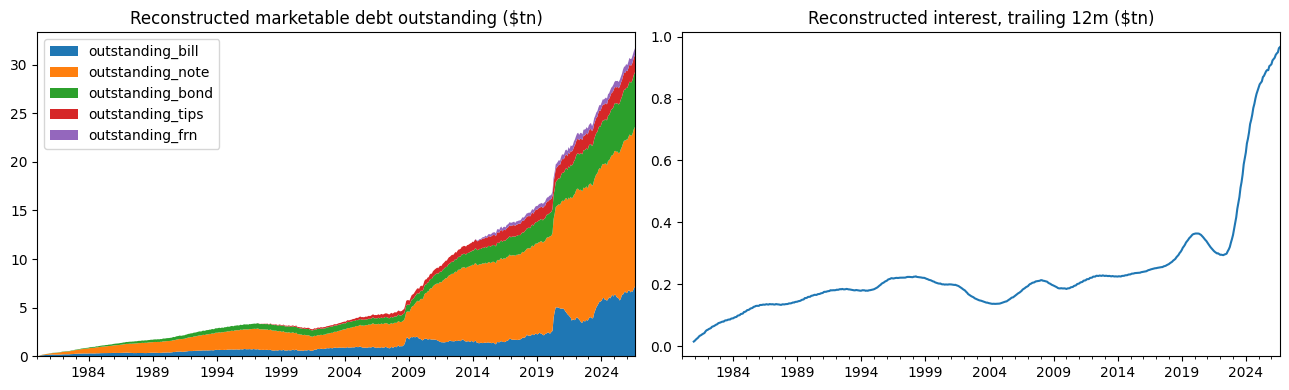

In [4]:
from bond_sim.data import load_auctions, load_macro_panel, load_mspd_summary, load_interest_expense, load_debt_to_penny
from bond_sim.data.fred import panel_wide
from bond_sim.engine.book import BondBook
from bond_sim.engine.validate import BookValidator
from bond_sim.sim.setup import realized_short_rate

auctions = load_auctions(as_of=AS_OF)
book = BondBook.from_auctions(auctions, grid, cfg.book)
w3m = panel_wide(load_macro_panel(["DGS3MO"], as_of=AS_OF, grid=grid), grid)
short = realized_short_rate(w3m, grid)
agg = book.aggregates(short_rate=short).frame
print(f"{book.N} tranches; by kind:", {k: int((book.kind == k).sum()) for k in ("bill", "note", "bond", "tips", "frn")})
hist = agg.loc[agg.index <= AS_OF]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(hist[[f"outstanding_{k}" for k in ("bill", "note", "bond", "tips", "frn")]] / 1e6).plot.area(ax=ax[0], linewidth=0)
ax[0].set_title("Reconstructed marketable debt outstanding ($tn)"); ax[0].set_xlabel("")
(hist["interest"].rolling(12).sum() / 1e6).plot(ax=ax[1]); ax[1].set_title("Reconstructed interest, trailing 12m ($tn)"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

**Validation, not calibration.** The book is compared to what the Treasury publishes and the gaps are reported,
never fitted away: bills/notes/bonds/FRN reconcile to within ~1.5% of MSPD Table 1; TIPS sit at ~0.83 because
the book carries nominal face without the inflation accrual (decision 0004); the 12-month interest ratio against
Treasury's accrued interest expense is the next gap to decompose by security type.

,mean_ratio_last_5y
ratio_bill,1.0080
ratio_note,1.0053
ratio_bond,1.0153
ratio_tips,0.8299
ratio_frn,0.9954
ratio_total,0.9940
ratio_interest_12m,0.8165


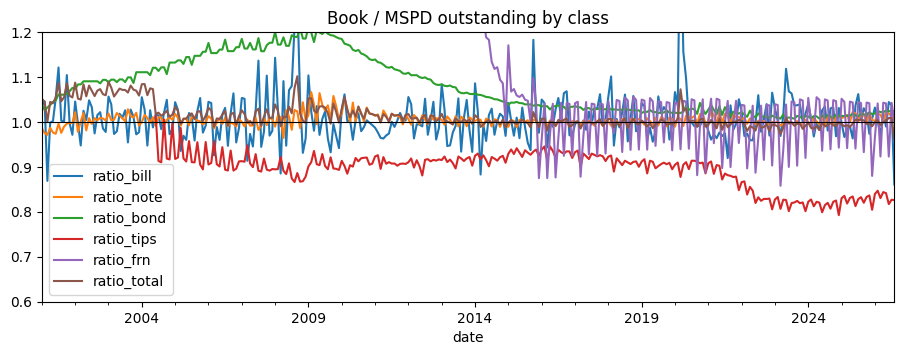

In [5]:
rep = BookValidator(book).run(load_mspd_summary(as_of=AS_OF), load_interest_expense(as_of=AS_OF),
                              load_debt_to_penny(as_of=AS_OF), short_rate=short)
display(rep.headline().round(4).to_frame())
ax = rep.outstanding[[c for c in rep.outstanding.columns if c.startswith("ratio_")]].plot(figsize=(11, 3.5), ylim=(0.6, 1.2))
ax.axhline(1, color="k", lw=0.8); ax.set_title("Book / MSPD outstanding by class"); plt.show()

## 3. Nothing is independent (decision 0003)

For every cross-group pair (fiscal x rates x macro x labor) on the quarterly panel: full-sample correlation,
rolling correlation and its range, a lead/lag scan, and Granger causality both ways with Benjamini-Hochberg
control over the whole grid. A wide rolling range means the relationship is regime-dependent and must not be
summarized by one number; the regime detector then asks whether those regimes coincide across pairs.

In [6]:
from bond_sim.analysis import CorrelationAnalyzer, RegimeDetector
from bond_sim.cli import THESIS_GROUPS, _quarterly_panel
ids = [s for g in THESIS_GROUPS.values() for s in g]
group_of = {s: g for g, ss in THESIS_GROUPS.items() for s in ss}
w = panel_wide(load_macro_panel(ids, as_of=AS_OF, grid=grid), grid)
wq = _quarterly_panel(w.loc[w.index <= AS_OF], ids)
an = CorrelationAnalyzer(wq, cfg.correlation, freq="Q")
rep_c = an.report(with_granger=True, group_of=group_of)
display(rep_c.head(12)[["a", "b", "full_corr", "rolling_min", "rolling_max", "best_lag", "leads",
                        "granger_a_to_b_sig", "granger_b_to_a_sig"]].round(3))

,a,b,full_corr,rolling_min,rolling_max,best_lag,leads,granger_a_to_b_sig,granger_b_to_a_sig
0,FDHBFRBN,ICSA,0.399,-0.776,0.962,0,None,True,True
1,DGS3MO,FDHBFRBN,-0.127,-0.832,0.809,-8,FDHBFRBN,False,False
2,CES5552200001,DGS3MO,0.030,-0.756,0.835,4,CES5552200001,False,False
3,FDHBFRBN,GDP,-0.320,-0.828,0.763,0,None,True,True
4,CPIAUCSL,UNRATE,-0.305,-0.879,0.688,0,None,False,False
5,A091RC1Q027SBEA,USCONS,0.265,-0.736,0.814,0,None,False,False
6,FDHBFRBN,UNRATE,0.367,-0.802,0.747,0,None,True,True
7,A091RC1Q027SBEA,CES5552200001,-0.209,-0.871,0.651,1,A091RC1Q027SBEA,False,False
8,CPIAUCSL,FYGFGDQ188S,-0.352,-0.863,0.637,0,None,False,False
9,A091RC1Q027SBEA,CES5553000001,0.288,-0.749,0.743,0,None,False,False


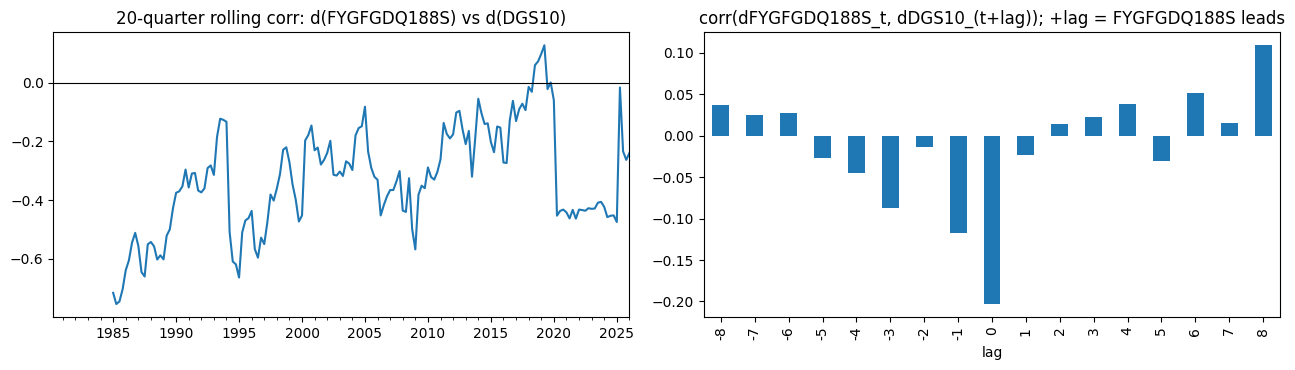

mean pairwise adjusted Rand index across 12 regime-dependent pairs: 0.109 (near 0 = pair-specific regimes; near 1 = one market-wide regime)


In [7]:
pair = ("FYGFGDQ188S", "DGS10")     # debt/GDP vs the 10y: the relationship the whole thesis turns on
r = an.analyze_pair(*pair)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
r.rolling.plot(ax=ax[0]); ax[0].axhline(0, color="k", lw=0.8); ax[0].set_title(f"20-quarter rolling corr: d({pair[0]}) vs d({pair[1]})")
r.lead_lag.plot.bar(ax=ax[1]); ax[1].set_title(f"corr(d{pair[0]}_t, d{pair[1]}_(t+lag)); +lag = {pair[0]} leads")
plt.tight_layout(); plt.show()
det = RegimeDetector(cfg.correlation)
top = rep_c[rep_c["regime_dependent"]].head(12)
labels = {f"{x.a}|{x.b}": det.label(an.rolling(x.a, x.b).dropna()) for x in top.itertuples()}
cons = det.consistency(labels)
off = cons.to_numpy()[~np.eye(len(cons), dtype=bool)]
print(f"mean pairwise adjusted Rand index across {len(labels)} regime-dependent pairs: {np.nanmean(off):.3f} "
      "(near 0 = pair-specific regimes; near 1 = one market-wide regime)")

## 4. The doom loop (Phase 4, decision 0005)

A quarterly VAR in levels on (10y, 3m, nominal growth, trailing-4Q primary balance, unemployment) supplies the
estimated cross-variable dynamics and the shock covariance. The fiscal premium (`sim/premium.py`, the thesis's
central open parameter P-01) is added on top of the base 10y from last quarter's debt/GDP, and its change is
transmitted to growth, the primary balance, and unemployment through the VAR's own estimated coefficients on the
lagged 10y. Debt accounting is monthly: the legacy book's exact schedules, a refinancing pool for new issuance,
deficits financed at the current bill/coupon blend.

In [8]:
from bond_sim.sim import MacroVAR, DoomLoopSimulator, premium_from_config, policy_from_name, LaborModel, RecoveryModel
from bond_sim.sim.macro import build_quarterly_state
from bond_sim.sim.setup import build_initial_state
from bond_sim.cli import SIM_SERIES
ws = panel_wide(load_macro_panel(SIM_SERIES + list(cfg.labor.sectors), as_of=AS_OF, grid=grid), grid)
ws = ws.loc[ws.index <= AS_OF]
q = build_quarterly_state(ws)
var = MacroVAR(max_lag=cfg.doomloop.var_max_lag).fit(q, start=cfg.doomloop.var_start)
print(f"VAR({var.lag}) on {len(var.sample)} quarters; max eigenvalue {var.max_eigenvalue():.3f} (stable if < 1)")
display(var.resid_corr().round(2)); display(var.long_run_means().round(2).to_frame("estimated long-run mean"))
init = build_initial_state(book, ws, q, load_mspd_summary(as_of=AS_OF), auctions, grid, AS_OF)
print({k: (round(v, 2) if isinstance(v, float) else v) for k, v in init.__dict__.items() if not isinstance(v, np.ndarray)})

VAR(3) on 166 quarters; max eigenvalue 0.961 (stable if < 1)


,r10,r3m,g_nom,pb,u
r10,1.00,0.52,0.31,0.13,-0.15
r3m,0.52,1.00,0.35,0.07,-0.24
g_nom,0.31,0.35,1.00,0.57,-0.80
pb,0.13,0.07,0.57,1.00,-0.73
u,-0.15,-0.24,-0.80,-0.73,1.00


,estimated long-run mean
r10,4.05
r3m,3.04
g_nom,5.48
pb,-1.85
u,5.25


{'debt_public_mm': 31828001.46, 'gdp_saar_mm': 32486066.0, 'r10_pct': 4.83, 'r3m_pct': 3.95, 'u_pct': 4.1, 'pb_pct_gdp': -1.83, 'g_nom_pct': 6.57, 'avg_new_maturity_months': 72.04, 'bill_share': 0.2, 'receipts_gdp_pct': 16.59}


**Policies on identical dice.** Every policy is a set of hooks on the same shock draws (common random numbers), so
the difference between two outcome distributions is the policy, not the randomness. Every magnitude inside the
policies is a placeholder (P-06 to P-09); the mechanics are what is being demonstrated here.

premium: linear: 2.0 bps per pt of debt/GDP above 100.0%


,P(trigger),median_years_to_trigger,median_end_debt_gdp,median_end_r10,median_end_u,median_end_interest_12m_gdp
policy,,,,,,
status_quo,0.49,16.17,106.32,4.40,5.15,4.00
no_layoff_mandate,0.80,11.00,208.46,5.21,5.12,8.23
austerity,0.00,6.67,18.45,3.84,5.76,1.46
monetization,0.00,NaN,0.00,13.04,1.14,0.19
growth_led,0.11,12.88,58.85,4.83,4.31,2.60


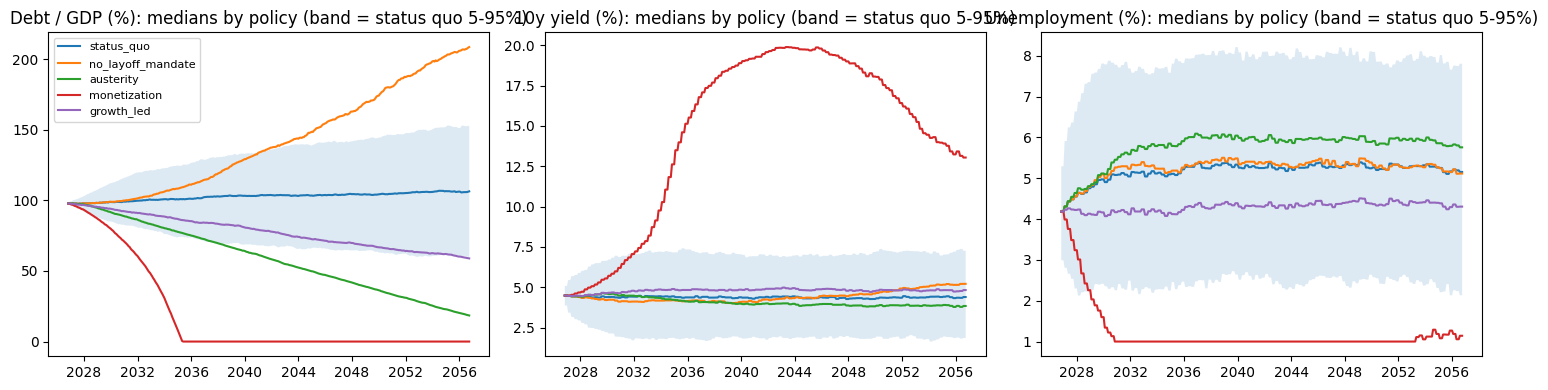

In [9]:
K = 1000
premium = premium_from_config(cfg.doomloop.risk_premium)
print("premium:", premium.describe())
HQ = (len(init.legacy_interest_mm) + 2) // 3
shocks = var.draw_shocks(K, HQ, np.random.default_rng(cfg.sim.seed))
results = {}
for name in cfg.policy.menu:
    sim = DoomLoopSimulator(cfg, var, premium, init, policy_from_name(name, cfg.policy))
    results[name] = sim.run(K=K, shocks=shocks, start=AS_OF + pd.DateOffset(months=1))
summary = pd.DataFrame([r.summary() for r in results.values()]).set_index("policy")
display(summary[["P(trigger)", "median_years_to_trigger", "median_end_debt_gdp", "median_end_r10", "median_end_u",
                 "median_end_interest_12m_gdp"]].round(2))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, v, title in zip(axes, ("debt_gdp", "r10", "u"), ("Debt / GDP (%)", "10y yield (%)", "Unemployment (%)")):
    for name, res in results.items():
        qq = res.quantiles(v)
        ax.plot(qq.index, qq["q50"], label=name)
        if name == "status_quo":
            ax.fill_between(qq.index, qq["q05"], qq["q95"], alpha=0.15)
    ax.set_title(f"{title}: medians by policy (band = status quo 5-95%)")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Who gets hurt, and for how long (Phases 5 and 7)

Sector employment growth is regressed on the unemployment change and lagged 10y changes; the residual covariance
across sectors is kept so sector shocks are drawn together. Recovery half-lives are measured on five US
episodes and on every simulated path (months from the unemployment peak until half the gap is closed).

In [10]:
labor = LaborModel(list(cfg.labor.sectors)).fit(ws, q)
display(labor.table().round(3))
rec = RecoveryModel()
display(rec.historical(ws["UNRATE"].dropna())[["peak_date", "peak_u", "trough_u", "half_life_months"]])
hl = {name: rec.simulated(res.paths["u"], init.u_pct) for name, res in results.items()}
display(pd.DataFrame({name: {"median_half_life_months": h.median(), "share_paths_with_downturn": h.notna().mean()}
                      for name, h in hl.items()}).T.round(2))

,beta_u,beta_r_sum,r2,n
USCONS,-1.335,0.180,0.493,182.0
CES5553000001,-0.971,0.394,0.736,146.0
CES3133600101,-3.834,0.194,0.800,146.0
CES5552200001,-0.210,-1.527,0.262,146.0
USFIRE,-0.372,-0.440,0.336,182.0
CES9091000001,-0.081,0.047,0.008,182.0
USPBS,-1.142,0.199,0.738,182.0
USTRADE,-1.347,-0.093,0.870,182.0
MANEMP,-1.087,0.688,0.698,182.0


,peak_date,peak_u,trough_u,half_life_months
name,,,,
volcker_1981,1982-11-01,10.8,6.3,12
early_1990s,1992-06-01,7.8,5.0,22
dotcom_2001,2003-06-01,6.3,3.8,24
gfc_2008,2009-10-01,10.0,4.4,46
covid_2020,2020-04-01,14.8,3.5,4


,median_half_life_months,share_paths_with_downturn
status_quo,12.0,0.95
no_layoff_mandate,18.0,0.94
austerity,15.0,0.94
monetization,6.0,0.82
growth_led,9.0,0.95


## 6. What is still a placeholder

`PARAMETERS.md` lists every number a human must decide (premium slope and form, trigger thresholds, the
no-layoff mandate's mechanics and cost, the austerity multiplier, monetization's inflation cost, the growth
uplift, anchors for the primary balance, the long-run 10y and the natural rate). Until those are set, the
probabilities above are properties of the placeholders, and the paper says so.